In [1]:
# Notebook to figure out what is happening with teff files
# KB 8/27/25

# Imports
%matplotlib widget
import plantcv.plantcv as pcv
import plantcv.geospatial as gcv
import numpy as np
import matplotlib.pyplot as plt


import rasterio
import fiona
from rasterio.mask import mask
from shapely.geometry import shape, MultiPoint, mapping

pcv.params.debug = "plot"

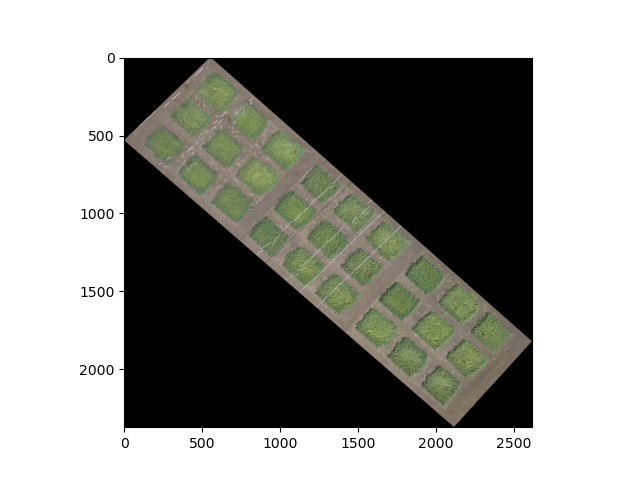

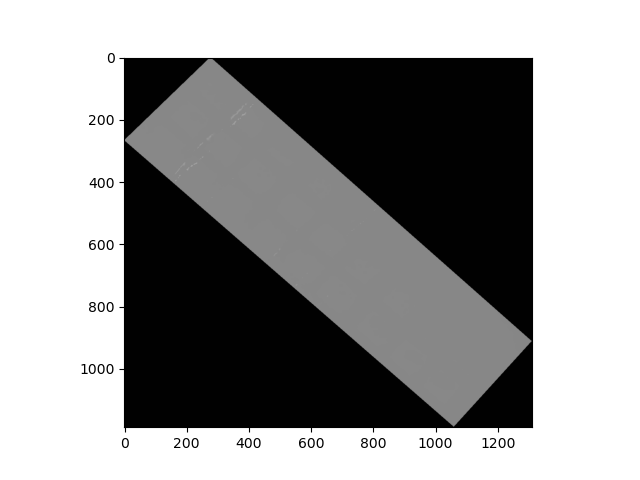

In [6]:
# Try with one image

img = gcv.read_geotif("/Users/hschuhl/Downloads/Fischer_South_81023.tif", bands="R,G,B", cropto="./tef_field.geojson")
img = gcv.read_geotif("./Fischer_South_81023_dem.tif", bands="R", cropto = "./tef_field.geojson")



[  1 134 135 136 137 138 139 140 141 142 143 144 145 146 147 148 149 150
 151 152 153 154 155 156 157 158 159 160 161 162]
[-32767.         134.90448    134.90466 ...    162.82147    162.82767
    162.82845]
(1188, 1309, 1)
[134.      134.90448 134.90466 ... 162.82147 162.82767 162.82845]


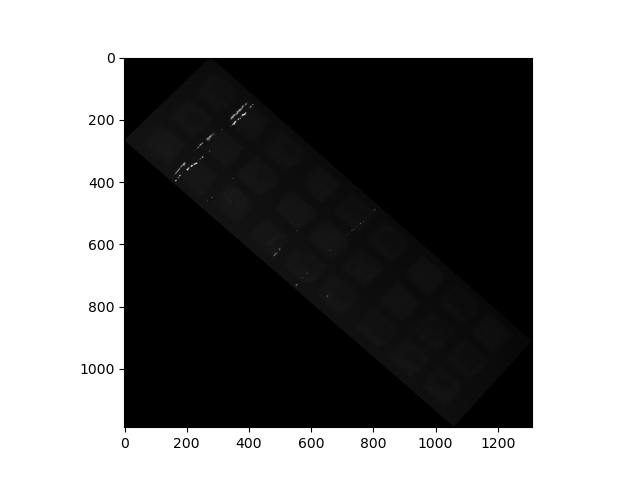

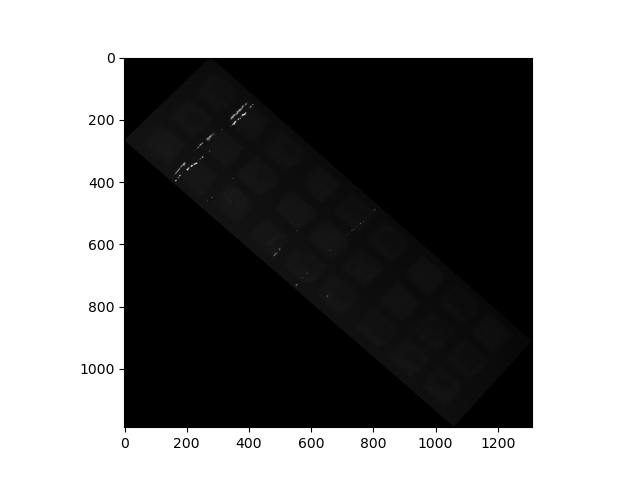

In [7]:
# Inspecting data values that exist in the tif 
psun = np.unique(img.pseudo_rgb)
print(psun)

whun = np.unique(img.array_data)
print(whun)

print(img.array_data.shape)

img_copy = img.array_data
img_copy[img_copy == min(np.unique(img.array_data))] = 134

whun = np.unique(img_copy)
print(whun)

gray = np.squeeze(img_copy)

rescaled = pcv.transform.rescale(gray, min_value=0, max_value=255)

pcv.plot_image(rescaled)

Use the `cutoff` parameter to remove the pixels of the DEM (belonging to powerlines) 


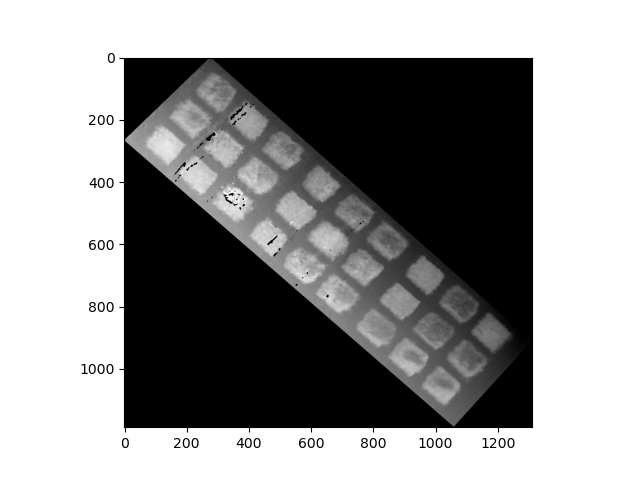

In [19]:
img = gcv.read_geotif("./Fischer_South_81023_dem.tif", bands="gray", 
                      cropto="./tef_field.geojson", cutoff=0.998)

In [ ]:
# Analyze coverage for each region in the geojson
bounds = gcv.analyze.height_percentile(dsm=img,
                           geojson="./shapefiles/experimental_plots.geojson",
                           lower=25,
                           upper=90,
                           label="default")